# Análise de Evasão de Clientes - Telecom X

## Importação das bibliotecas

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)


## Carregamento e leitura do dataset

In [3]:
arquivo_dados = "TelecomX_Data.json"

with open(arquivo_dados, encoding="utf-8") as arquivo:
    conteudo_json = json.load(arquivo)

dados_clientes = pd.json_normalize(conteudo_json)

dados_clientes.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


## Estrutura do dataset

In [ ]:

dados_clientes.columns = dados_clientes.columns.str.replace(".", "_", regex=False)

dados_clientes["account_Charges_Total"] = pd.to_numeric(
    dados_clientes["account_Charges_Total"],
    errors="coerce"
)


dados_clientes["Churn"] = dados_clientes["Churn"].replace("", np.nan)

dados_clientes["Churn_flag"] = dados_clientes["Churn"].apply(
    lambda valor: 1 if valor == "Yes" else 0 if valor == "No" else np.nan
)


dados_clientes.info()



### Estrutura do Dataset e Descrição das Variáveis

Após a etapa de extração e tratamento inicial dos dados, é importante compreender a estrutura do dataset e o significado das variáveis presentes. Esse entendimento ajuda a relacionar os dados técnicos com o contexto do problema de negócio, que neste projeto é a evasão de clientes (churn).

O conjunto de dados contém informações sobre características dos clientes, serviços contratados, tempo de relacionamento com a empresa e dados de faturamento. Essas variáveis permitem analisar possíveis fatores que podem influenciar o cancelamento do serviço.

As variáveis do dataset podem ser organizadas em diferentes grupos.

Identificador

customerID: identificador único de cada cliente. Essa variável serve apenas para identificação e normalmente não é utilizada em análises estatísticas ou modelos preditivos.

Variável alvo

Churn: indica se o cliente cancelou ou permaneceu utilizando o serviço da empresa.

Churn_bin: variável criada para representar o churn em formato numérico, onde 1 indica cancelamento e 0 indica permanência. Essa transformação facilita análises quantitativas e possíveis modelos de previsão.

Variáveis demográficas

Essas variáveis representam características pessoais dos clientes.

customer_gender

customer_SeniorCitizen

customer_Partner

customer_Dependents

Relacionamento com a empresa

Essas variáveis descrevem o histórico de relacionamento entre o cliente e a empresa.

customer_tenure: tempo de permanência do cliente na empresa, medido em meses.

account_Contract: tipo de contrato contratado pelo cliente.

Serviços contratados

Essas variáveis indicam os serviços adicionais utilizados pelos clientes.

phone_PhoneService

phone_MultipleLines

internet_InternetService

internet_OnlineSecurity

internet_OnlineBackup

internet_DeviceProtection

internet_TechSupport

internet_StreamingTV

internet_StreamingMovies

Faturamento e pagamento

Essas variáveis estão relacionadas à cobrança e forma de pagamento dos serviços.

account_PaperlessBilling

account_PaymentMethod

account_Charges_Monthly

account_Charges_Total

Durante a etapa de preparação dos dados, algumas transformações foram realizadas para melhorar a organização e facilitar as análises posteriores. Entre essas transformações estão a padronização dos nomes das colunas, a conversão de valores financeiros para formato numérico e a criação de uma variável binária para representar o churn.

Essas etapas tornam o dataset mais consistente e preparado para a realização da análise exploratória de dados, que permitirá identificar padrões e possíveis fatores associados à evasão de clientes.

## Visão geral dos dados

In [5]:
dados_clientes.describe(include='all')

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,Churn_flag
count,7267,7043,7267,7267.000000,7267,7267,7267.000000,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267.000000,7256.000000,7043.000000
unique,7267,2,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,NaN
top,9995-HOTOH,No,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,NaN
freq,1,5174,3675,NaN,3749,5086,NaN,6560,3495,3198,3608,3182,3195,3582,2896,2870,4005,4311,2445,NaN,NaN,NaN
mean,NaN,NaN,NaN,0.162653,NaN,NaN,32.346498,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.720098,2280.634213,0.265370
std,NaN,NaN,NaN,0.369074,NaN,NaN,24.571773,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.129572,2268.632997,0.441561
min,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,0.000000
25%,NaN,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.425000,400.225000,0.000000
50%,NaN,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.300000,1391.000000,0.000000
75%,NaN,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.875000,3785.300000,1.000000


In [6]:
dados_clientes["Churn"].value_counts(normalize=False, dropna=False)

,count
Churn,
No,5174
Yes,1869
NaN,224


## Distribuição da variável Churn

Nesta etapa foi analisada a distribuição da variável Churn, que representa o cancelamento ou permanência dos clientes no serviço da empresa.

Essa verificação é importante para entender quantos clientes permaneceram e quantos cancelaram o serviço, além de identificar possíveis valores ausentes na base de dados.

A análise dessa variável é fundamental para o projeto, pois ela representa o principal indicador de evasão de clientes.

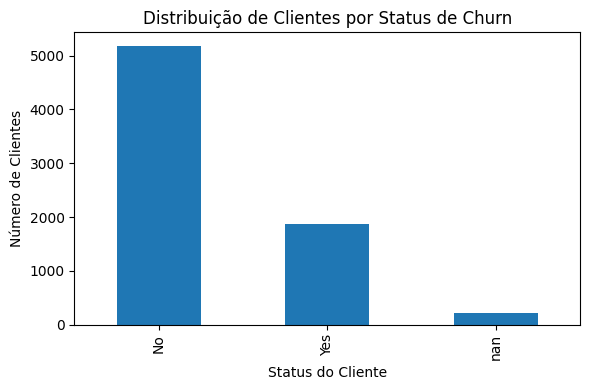

In [7]:
contagem_churn = dados_clientes["Churn"].value_counts(dropna=False)

plt.figure(figsize=(6,4))

contagem_churn.plot(
    kind="bar"
)

plt.title("Distribuição de Clientes por Status de Churn")
plt.xlabel("Status do Cliente")
plt.ylabel("Número de Clientes")

plt.tight_layout()
plt.show()

Observa-se que a maior parte dos clientes permaneceu utilizando os serviços da empresa, enquanto uma parcela menor realizou o cancelamento. Essa informação indica que existe evasão de clientes, mas em menor proporção em relação ao total de clientes da base.

In [8]:
taxa_churn_contrato = (
    dados_clientes
    .groupby("account_Contract")
    ["Churn_flag"]
    .mean()
    .sort_values(ascending=False)
)

taxa_churn_contrato

,Churn_flag
account_Contract,
Month-to-month,0.427097
One year,0.112695
Two year,0.028319


Nesta etapa foi analisada a relação entre o tipo de contrato dos clientes e a taxa de churn. O objetivo dessa análise é verificar se determinados tipos de contrato apresentam maior tendência de cancelamento.

Para isso, foi calculada a média da variável binária de churn para cada categoria de contrato. Como essa variável assume valor 1 para clientes que cancelaram e 0 para clientes que permaneceram, a média representa a proporção de cancelamentos dentro de cada tipo de contrato.

A visualização em gráfico facilita a identificação de padrões e permite observar quais tipos de contrato apresentam maior taxa de evasão de clientes.

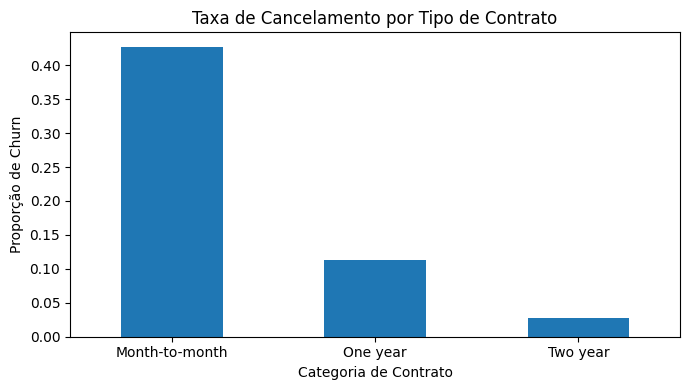

In [9]:
plt.figure(figsize=(7,4))

taxa_churn_contrato.plot(
    kind="bar"
)

plt.title("Taxa de Cancelamento por Tipo de Contrato")
plt.xlabel("Categoria de Contrato")
plt.ylabel("Proporção de Churn")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [10]:
tenure_medio_churn = (
    dados_clientes
    .groupby("Churn")["customer_tenure"]
    .mean()
    .round(2)
)

tenure_medio_churn

,customer_tenure
Churn,
No,37.57
Yes,17.98


###Tempo médio de permanência dos clientes

Nesta etapa foi analisado o tempo médio de permanência dos clientes na empresa (customer_tenure) em relação ao status de churn. O objetivo é verificar se existe diferença no tempo de relacionamento entre clientes que permaneceram e clientes que cancelaram o serviço.

A análise do tempo médio de permanência pode indicar se clientes mais novos apresentam maior tendência ao cancelamento, o que pode ajudar a identificar padrões de evasão e orientar estratégias de retenção.

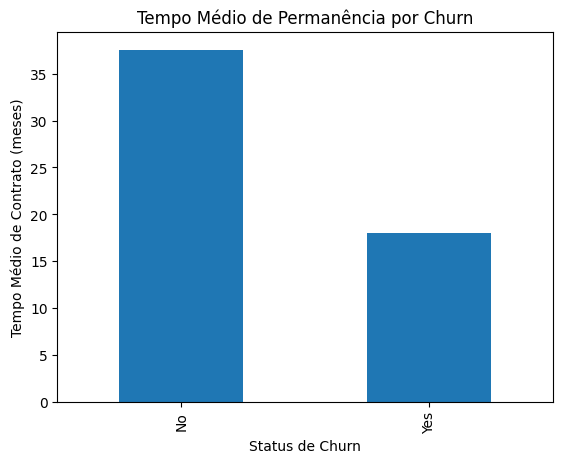

In [12]:
plt.figure()

dados_clientes.groupby("Churn")["customer_tenure"].mean().plot(kind="bar")

plt.title("Tempo Médio de Permanência por Churn")
plt.xlabel("Status de Churn")
plt.ylabel("Tempo Médio de Contrato (meses)")

plt.show()

Clientes que permanecem na empresa e clientes que cancelam o serviço podem apresentar diferenças no tempo de relacionamento com a empresa. Nesta etapa foi calculado o tempo médio de permanência dos clientes (customer_tenure) para cada grupo de churn.

Essa análise ajuda a identificar se clientes com menor tempo de contrato apresentam maior tendência de cancelamento.

In [13]:
servicos_internet = [
    "internet_OnlineSecurity",
    "internet_OnlineBackup",
    "internet_DeviceProtection",
    "internet_TechSupport",
    "internet_StreamingTV",
    "internet_StreamingMovies"
]

for servico in servicos_internet:

    print(f"\nAnálise do serviço: {servico}")

    taxa_churn_servico = (
        dados_clientes
        .groupby(servico)["Churn_flag"]
        .mean()
    )

    print(taxa_churn_servico)


Análise do serviço: internet_OnlineSecurity
internet_OnlineSecurity
No                     0.417667
No internet service    0.074050
Yes                    0.146112
Name: Churn_flag, dtype: float64

Análise do serviço: internet_OnlineBackup
internet_OnlineBackup
No                     0.399288
No internet service    0.074050
Yes                    0.215315
Name: Churn_flag, dtype: float64

Análise do serviço: internet_DeviceProtection
internet_DeviceProtection
No                     0.391276
No internet service    0.074050
Yes                    0.225021
Name: Churn_flag, dtype: float64

Análise do serviço: internet_TechSupport
internet_TechSupport
No                     0.416355
No internet service    0.074050
Yes                    0.151663
Name: Churn_flag, dtype: float64

Análise do serviço: internet_StreamingTV
internet_StreamingTV
No                     0.335231
No internet service    0.074050
Yes                    0.300702
Name: Churn_flag, dtype: float64

Análise do serviço: i

## Churn em relação aos serviços adicionais

Nesta etapa foi analisada a relação entre os serviços adicionais contratados pelos clientes e a taxa de churn. O objetivo é verificar se a presença ou ausência de determinados serviços pode influenciar a probabilidade de cancelamento.

Para cada serviço adicional disponível no dataset, foi calculada a taxa média de churn entre os clientes que possuem e os que não possuem o serviço. Essa análise permite identificar possíveis padrões de comportamento relacionados ao uso dos serviços oferecidos pela empresa.

##Análise de Correlação entre Variáveis


Como parte adicional da análise exploratória, foi realizada uma análise de correlação entre algumas variáveis do dataset. O objetivo dessa etapa é identificar possíveis relações entre características dos clientes e o comportamento de churn.

A análise de correlação pode auxiliar na identificação de variáveis mais relevantes para modelos preditivos, além de contribuir para a compreensão do comportamento dos clientes.

Uma das hipóteses consideradas nesta análise é que clientes que utilizam maior quantidade de serviços tendem a apresentar menor probabilidade de cancelamento. Esse tipo de análise pode ajudar a orientar estratégias de retenção e melhorar o entendimento dos fatores que influenciam a evasão de clientes.

## Conclusões da Análise Exploratória de Dados (EDA)

A análise exploratória dos dados permitiu identificar alguns padrões importantes relacionados à evasão de clientes (churn) na base de dados da Telecom X.

Um dos fatores que apresentou maior relação com o churn foi o tipo de contrato. Observou-se que clientes com contratos mensais apresentam maior taxa de cancelamento quando comparados a clientes com contratos de maior duração.

Outro aspecto identificado foi o tempo de permanência do cliente na empresa. Clientes com menor tempo de relacionamento tendem a apresentar maior probabilidade de cancelar o serviço.

Além disso, a análise dos serviços adicionais de internet indicou que clientes que utilizam mais serviços, como suporte técnico ou segurança online, tendem a apresentar menor taxa de churn. Isso pode indicar que clientes mais engajados com os serviços da empresa possuem maior tendência de permanecer.

De forma geral, os resultados da análise exploratória indicam que fatores relacionados ao relacionamento do cliente com a empresa, como tipo de contrato, tempo de permanência e serviços contratados, possuem forte influência no comportamento de cancelamento.

A partir dessas observações, o conjunto de dados encontra-se preparado para etapas futuras de análise, como engenharia de variáveis (feature engineering) e modelagem preditiva, que podem ser utilizadas para prever o risco de churn e apoiar estratégias de retenção de clientes.